Hacemos los imports 

In [1]:
import sys
!{sys.executable} -m pip install tensorflow
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install seaborn
!{sys.executable} -m pip install scikit-learn



  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached idna-3.13-py3-none-any.whl.metadata (8.0 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.4.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
df_partida = pd.read_csv("dataset.csv")

campos_borrar = ['Class', 'Brand', 'Acquisition', 'Concentration', 'Concentration_Class']

#Campos para adaptar el dataset de prueba a los datos de verdad
campos_nuevos = ["A_410", "B_435", "C_460", "D_485", "E_510", "F_535", "G_560", "H_585",
                    "R_610", "I_645", "S_680", "J_705", "T_730", "U_760", "V_810", "W_860",
                    "K_900", "L_940"]
df = pd.DataFrame()
df_modificado = df_partida.drop(campos_borrar, axis = 1)
y = df_partida['Class']

posicion_campo = 0
for i in range (len(campos_nuevos)):
    df[campos_nuevos[i]] = df_modificado.iloc[:,[posicion_campo]]
    posicion_campo = posicion_campo *2

X = df

#Para el XGBoost hay que hacer esto para que las clases sean un número y cambiarla en la asignación
le = LabelEncoder()
y_raw = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X , y_raw ,test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype('float32')
X_test_scaled = scaler.transform(X_test).astype('float32')

#Neuronas capa de salida
num_clases = len(np.unique(y_train))

      A_410     B_435     C_460     D_485     E_510     F_535     G_560  \
0  0.983576  0.983576  0.983576  0.983576  0.983576  0.983576  0.983576   
1  1.000639  1.000639  1.000639  1.000639  1.000639  1.000639  1.000639   
2  1.048612  1.048612  1.048612  1.048612  1.048612  1.048612  1.048612   
3  0.995192  0.995192  0.995192  0.995192  0.995192  0.995192  0.995192   
4  0.986593  0.986593  0.986593  0.986593  0.986593  0.986593  0.986593   

      H_585     R_610     I_645     S_680     J_705     T_730     U_760  \
0  0.983576  0.983576  0.983576  0.983576  0.983576  0.983576  0.983576   
1  1.000639  1.000639  1.000639  1.000639  1.000639  1.000639  1.000639   
2  1.048612  1.048612  1.048612  1.048612  1.048612  1.048612  1.048612   
3  0.995192  0.995192  0.995192  0.995192  0.995192  0.995192  0.995192   
4  0.986593  0.986593  0.986593  0.986593  0.986593  0.986593  0.986593   

      V_810     W_860     K_900     L_940  
0  0.983576  0.983576  0.983576  0.983576  
1  1.00063

In [8]:
def create_dataset(X, y, batch_size=128, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((X,y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X))
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

In [9]:
train_ds = create_dataset(X_train_scaled, y_train)
test_ds = create_dataset(X_test_scaled, y_test, shuffle=False)

Iniciando entrenamiento...
Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1402 - loss: 2.4137 - val_accuracy: 0.1489 - val_loss: 2.3633 - learning_rate: 0.0010
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1452 - loss: 2.3726 - val_accuracy: 0.1478 - val_loss: 2.3609 - learning_rate: 0.0010
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1510 - loss: 2.3656 - val_accuracy: 0.1546 - val_loss: 2.3612 - learning_rate: 0.0010
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1519 - loss: 2.3637 - val_accuracy: 0.1555 - val_loss: 2.3602 - learning_rate: 0.0010
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1511 - loss: 2.3622 - val_accuracy: 0.1530 - val_loss: 2.3588 - learning_rate: 0.0010
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1527 - loss: 2.3614 - val_accuracy: 0.1528 - val_loss: 2.3590 - learning_rate: 0.0010
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accurac

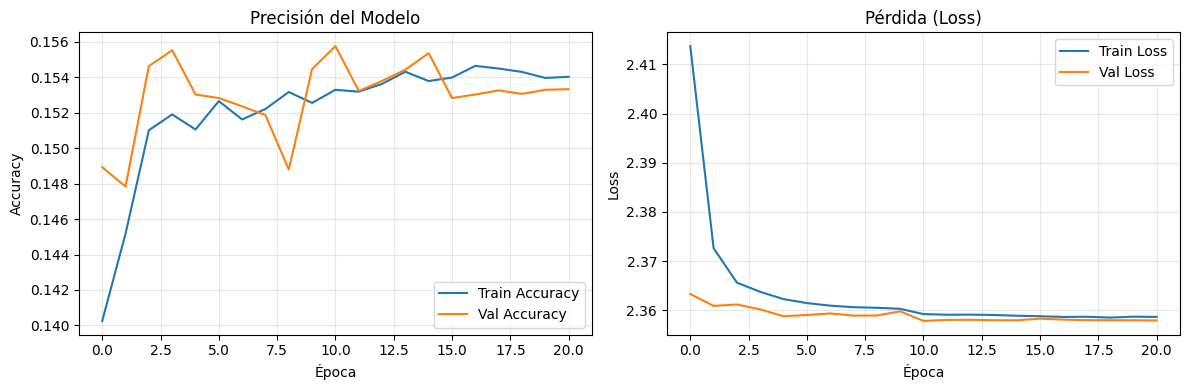


EVALUACIÓN EN TEST

Loss:     2.3578
Accuracy: 0.1558  (15.58%)

REPORTE POR CLASE
              precision    recall  f1-score   support

           0      0.000     0.000     0.000      2766
           1      0.166     0.016     0.030      4100
           2      0.000     0.000     0.000      2661
           3      0.173     0.653     0.274      4514
           4      0.132     0.397     0.198      4177
           5      0.000     0.000     0.000      2015
           6      0.000     0.000     0.000      2112
           7      0.000     0.000     0.000      2167
           8      0.000     0.000     0.000      2045
           9      0.000     0.000     0.000      1470
          10      0.000     0.000     0.000      1510
          11      0.000     0.000     0.000       463

    accuracy                          0.156     30000
   macro avg      0.039     0.089     0.042     30000
weighted avg      0.067     0.156     0.073     30000



c:\Users\Victus-LP\anaconda3\envs\TFG\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Victus-LP\anaconda3\envs\TFG\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Victus-LP\anaconda3\envs\TFG\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

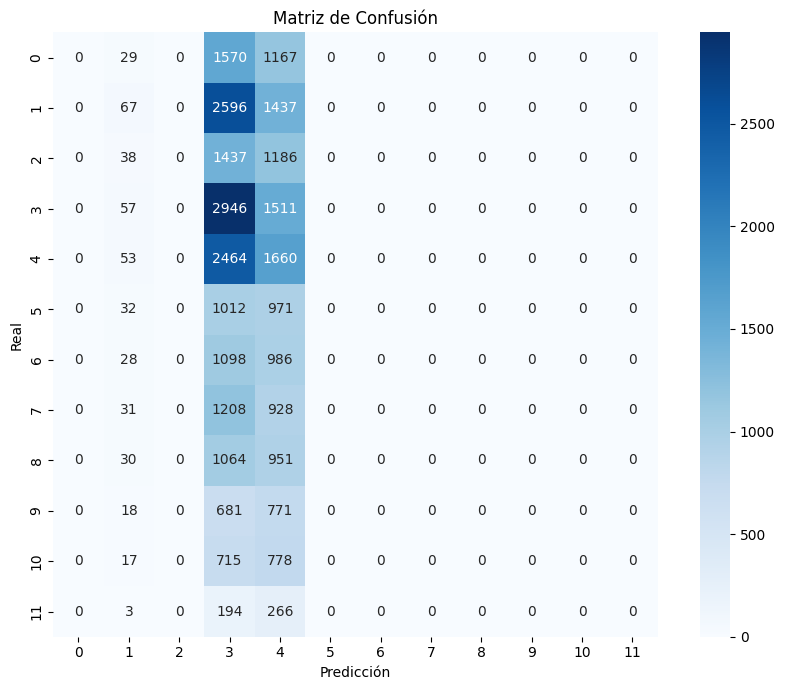

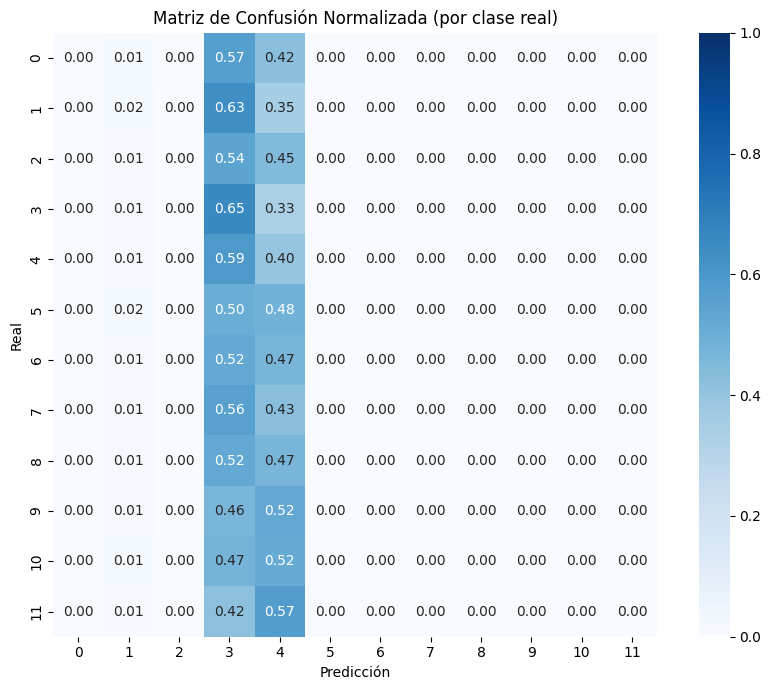


CONFIANZA DEL MODELO
Confianza media cuando acierta: 0.158
Confianza media cuando falla:   0.153


In [10]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    #Capa 1:
    layers.Dense(512, kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    
    #Capa 2:                            # Regularización contra overfitting
    layers.Dense(256, kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.2),
    
    #Capa 3:
    layers.Dense(128, kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.3),
    
    #Capa de salida
    layers.Dense(num_clases, activation='softmax')    # Softmax para multiclase
])


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Checpoints para guardar el mejor resultado
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "mejor_resultado.keras",
    save_best_only=True,
    monitor="val_loss",
    mode="min"
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-6
    ),
    checkpoint_cb
]

# Calcular pesos basados en y_train
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

print("Iniciando entrenamiento...")
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

# Curbas de entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("EVALUACIÓN EN TEST")
print("="*60)

loss, accuracy = model.evaluate(test_ds, verbose=0)
print(f"\nLoss:     {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)")

# Predicciones
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Métricas por clase
print("\n" + "="*60)
print("REPORTE POR CLASE")
print("="*60)
print(classification_report(y_true, y_pred, digits=3))

# Matroz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    square=True
)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    cbar=True,
    square=True,
    vmin=0,
    vmax=1
)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión Normalizada (por clase real)')
plt.tight_layout()
plt.show()

confianzas = np.max(y_pred_probs, axis=1)
aciertos = (y_pred == y_true)

print("\n" + "="*60)
print("CONFIANZA DEL MODELO")
print("="*60)
print(f"Confianza media cuando acierta: {confianzas[aciertos].mean():.3f}")
print(f"Confianza media cuando falla:   {confianzas[~aciertos].mean():.3f}")